In [15]:
import pandas as pd

# !!! Veri setinin bulunduğu dosya yolunu ekleyiniz !!!
dosya_yolu = r"C:\Users\admin\Desktop\ders\3. sinif\veri bilimi\alkol_kullanma_veri_bilimi\alkol_verisi.xls"

# Veriyi tam yolunu göstererek yüklüyoruz
df_raw = pd.read_excel(dosya_yolu, header=None)

# Alternatif veri seti yükleme
# df_raw = pd.read_excel('alkol_verisi.xls', header=None)

# Başarıyla yüklendiğini görmek için ilk 10 satırı yazdıralım
print("Veri başarıyla yüklendi!")
display(df_raw.head(10))

Veri başarıyla yüklendi!


,0,1,2,3,4,5,6,7,8,9,10,11
0,Bireylerin alkol kullanma durumunun cinsiyet v...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,The percentage of individuals' status of alcoh...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,[15+ yaş - age],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(%)
4,NaN,2019,NaN,NaN,NaN,2022,NaN,NaN,NaN,2025,NaN,NaN
5,NaN,Toplam\nTotal,Erkek\nMale,Kadın\nFemale,NaN,Toplam\nTotal,Erkek\nMale,Kadın\nFemale,NaN,Toplam\nTotal,Erkek\nMale,Kadın\nFemale
6,Kullanan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Consumers,14.859799,23.309798,6.60752,NaN,12.093402,18.446973,5.867369,NaN,12.575078,18.658276,6.624066
8,15-24,11.37909,16.368841,6.248088,NaN,8.343656,11.590164,4.931859,NaN,7.622182,11.119453,3.881097
9,25-34,20.693229,30.947662,10.478067,NaN,17.524708,24.225033,10.764031,NaN,18.033008,24.914197,11.146672


Ben bu veri setini yüklerken bir hata sebebiyle veri setinin tam dosya yolunu bir değişkene atayıp oradan çektim. alternatif olarak direkt dosya içerisinden çekilebilmesi için bir satır yazdım.

In [16]:
# 1. Sütun isimlerini yıl ve cinsiyete göre elle anlamlı hale getirelim
# Excel dönüştürülürken aralarda oluşan boş sütunları da (bos_1, bos_2) listeye ekliyoruz
kolon_isimleri = [
    'yas_grubu',
    '2019_Toplam', '2019_Erkek', '2019_Kadin', 'bos_1',
    '2022_Toplam', '2022_Erkek', '2022_Kadin', 'bos_2',
    '2025_Toplam', '2025_Erkek', '2025_Kadin'
]
df_raw.columns = kolon_isimleri

# 2. Excel kaynaklı o tamamen boş olan separator (bos_1, bos_2) sütunlarını kaldıralım
df_temiz = df_raw.drop(columns=['bos_1', 'bos_2'])

# 3. Veri setindeki iki ana bloğu (Kullananlar ve Hiç Kullanmayanlar) ayıralım
# TÜİK dosya yapısına göre yaş gruplarının satır indekslerini birebir yakalıyoruz

# --- 1. BLOK: ALKOL KULLANANLAR ---
# 8. satırdan 14. satıra kadar olan yaş gruplarını alıyoruz (15-24, 25-34... 65+)
df_kullanan = df_temiz.iloc[8:14].copy()
df_kullanan['yas_grubu'] = df_kullanan['yas_grubu'].str.strip()     # Yazı başındaki boşlukları temizler
df_kullanan.set_index('yas_grubu', inplace=True)                    # Yaş gruplarını satır başı yapar

# --- 2. BLOK: HİÇ ALKOL KULLANMAYANLAR ---
# 16. satırdan 22. satıra kadar olan yaş gruplarını alıyoruz
df_hic_kullanmayan = df_temiz.iloc[16:22].copy()
df_hic_kullanmayan['yas_grubu'] = df_hic_kullanmayan['yas_grubu'].str.strip()
df_hic_kullanmayan.set_index('yas_grubu', inplace=True)

# 4. TİP DÖNÜŞÜMÜ : Tüm verileri metinden matematiksel 'float' tipine çeviriyoruz
df_kullanan = df_kullanan.astype(float)
df_hic_kullanmayan = df_hic_kullanmayan.astype(float)

# Sonuçları ekrana bastırıp kontrol edelim
print("=== 1) TERTEMİZ ALKOL KULLANANLAR TABLOSU ===")
display(df_kullanan)

print("\n=== 2) TERTEMİZ HİÇ ALKOL KULLANMAYANLAR TABLOSU ===")
display(df_hic_kullanmayan)

=== 1) TERTEMİZ ALKOL KULLANANLAR TABLOSU ===


,2019_Toplam,2019_Erkek,2019_Kadin,2022_Toplam,2022_Erkek,2022_Kadin,2025_Toplam,2025_Erkek,2025_Kadin
yas_grubu,,,,,,,,,
15-24,11.379090,16.368841,6.248088,8.343656,11.590164,4.931859,7.622182,11.119453,3.881097
25-34,20.693229,30.947662,10.478067,17.524708,24.225033,10.764031,18.033008,24.914197,11.146672
35-44,19.770272,30.754391,8.682305,15.168377,23.102353,7.201161,16.694118,23.631808,9.756999
45-54,14.152611,22.239190,6.007879,12.167952,19.184477,5.130652,13.225163,19.754956,6.731445
55-64,12.480011,21.311057,3.858764,10.994133,18.617649,3.558856,11.002190,17.772782,4.354400
65-74,8.244486,15.048322,2.319399,6.685828,12.205911,1.825621,8.128305,13.964634,2.898332



=== 2) TERTEMİZ HİÇ ALKOL KULLANMAYANLAR TABLOSU ===


,2019_Toplam,2019_Erkek,2019_Kadin,2022_Toplam,2022_Erkek,2022_Kadin,2025_Toplam,2025_Erkek,2025_Kadin
yas_grubu,,,,,,,,,
Former drinkers,10.709540,17.552215,4.026976,4.584493,7.478920,1.748167,4.728319,7.386543,2.127858
15-24,4.390560,5.736260,3.006765,1.615842,2.336537,0.858453,1.501091,1.754877,1.229613
25-34,8.890229,12.159592,5.633387,3.851555,5.226572,2.464152,3.459299,4.340203,2.577736
35-44,10.632428,15.955610,5.258919,4.180333,6.434361,1.916861,4.260444,5.727225,2.793783
45-54,12.306952,20.888918,3.663271,4.889795,7.492934,2.278949,4.840727,7.954729,1.743929
55-64,16.575159,29.918861,3.548464,6.995422,12.485344,1.641056,7.169007,11.887885,2.535718


=== VERİ SETİNİN TEMEL İSTATİSTİKSEL ÖZETİ ===


,2019_Toplam,2019_Erkek,2019_Kadin,2022_Toplam,2022_Erkek,2022_Kadin,2025_Toplam,2025_Erkek,2025_Kadin
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,14.453283,22.778244,6.265751,11.814109,18.154264,5.568696,12.450828,18.526305,6.461491
std,4.882445,6.835696,3.000581,4.074382,5.311953,3.108181,4.332769,5.378085,3.366854
min,8.244486,15.048322,2.319399,6.685828,11.590164,1.825621,7.622182,11.119453,2.898332
25%,11.654320,17.604395,4.396043,9.006275,13.808845,3.902106,8.846776,14.916671,3.999422
50%,13.316311,21.775124,6.127984,11.581042,18.901063,5.031255,12.113677,18.763869,5.542922
75%,18.365857,28.625591,8.073751,14.418271,22.122884,6.683534,15.826880,22.662595,9.000610
max,20.693229,30.947662,10.478067,17.524708,24.225033,10.764031,18.033008,24.914197,11.146672


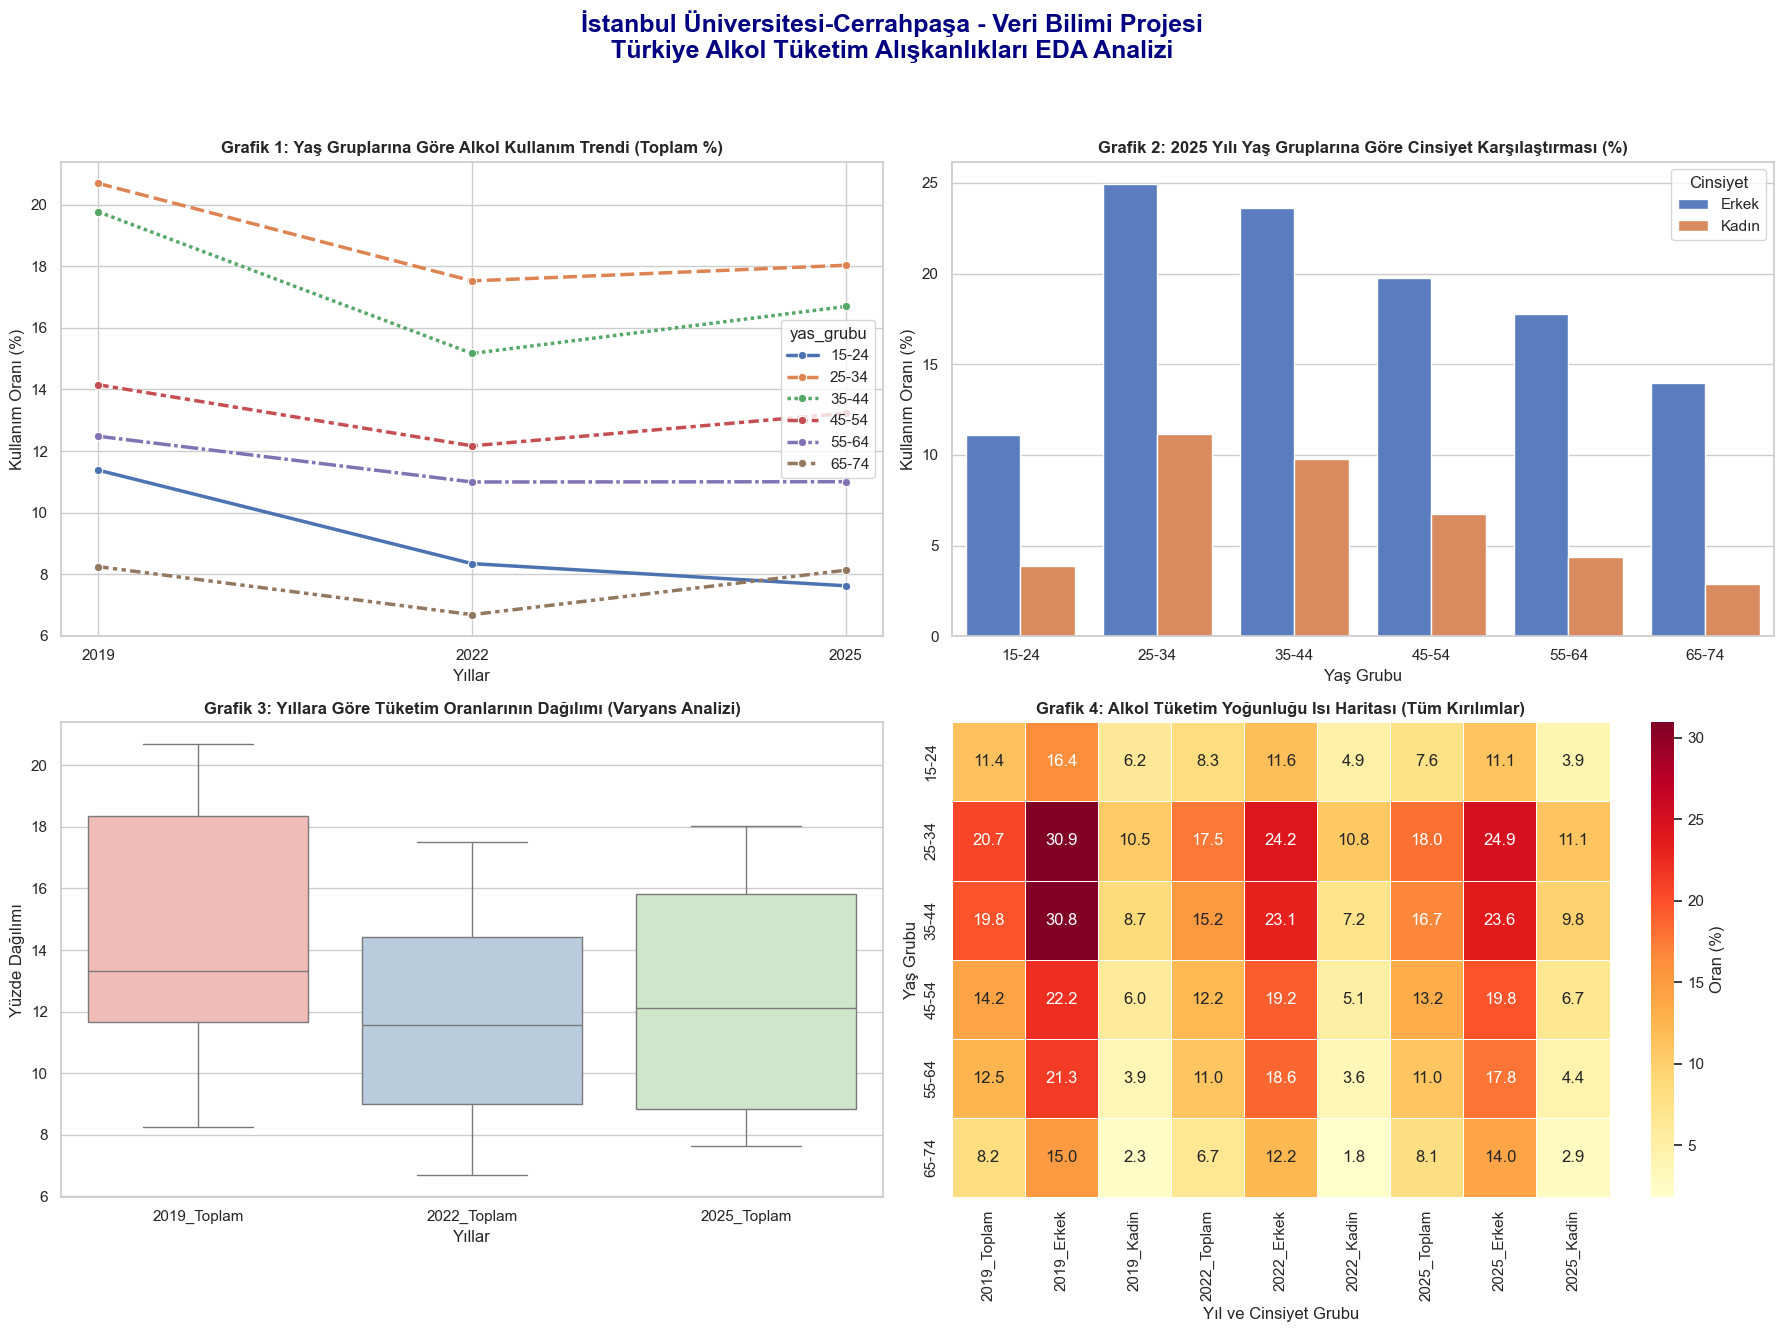

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin düzgün görünmesi için seaborn temasını ayarlayalım
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# =============================================================================
# ADIM 1: TEMEL İSTATİSTİKLER 
# =============================================================================
print("=== VERİ SETİNİN TEMEL İSTATİSTİKSEL ÖZETİ ===")
display(df_kullanan.describe())

# Grafiklerin alt alta düzgün çıkması için büyük bir figür alanı oluşturalım
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('İstanbul Üniversitesi-Cerrahpaşa - Veri Bilimi Projesi\nTürkiye Alkol Tüketim Alışkanlıkları EDA Analizi', fontsize=18, fontweight='bold', color='navy')

# =============================================================================
# GRAFİK 1: Çizgi Grafik (Line Plot) - Zaman İçinde Yaş Gruplarının Değişimi
# =============================================================================
# Sadece 'Toplam' sütunlarını seçip yıllara göre trendi görelim
df_trend = df_kullanan[['2019_Toplam', '2022_Toplam', '2025_Toplam']].T
df_trend.index = ['2019', '2022', '2025']

sns.lineplot(data=df_trend, marker='o', linewidth=2.5, ax=axes[0,0])
axes[0,0].set_title('Grafik 1: Yaş Gruplarına Göre Alkol Kullanım Trendi (Toplam %)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Yıllar')
axes[0,0].set_ylabel('Kullanım Oranı (%)')

# =============================================================================
# GRAFİK 2: Kümelenmiş Sütun Grafik (Bar Plot) - En Güncel Yılda Cinsiyet Farkı (2025)
# =============================================================================
# 2025 yılı erkek ve kadın verilerini yan yana getirelim
df_2025_cinsiyet = df_kullanan[['2025_Erkek', '2025_Kadin']].reset_index()
df_melted = df_2025_cinsiyet.melt(id_vars='yas_grubu', var_name='Cinsiyet', value_name='Yüzde')
df_melted['Cinsiyet'] = df_melted['Cinsiyet'].replace({'2025_Erkek': 'Erkek', '2025_Kadin': 'Kadın'})

sns.barplot(x='yas_grubu', y='Yüzde', hue='Cinsiyet', data=df_melted, palette='muted', ax=axes[0,1])
axes[0,1].set_title('Grafik 2: 2025 Yılı Yaş Gruplarına Göre Cinsiyet Karşılaştırması (%)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Yaş Grubu')
axes[0,1].set_ylabel('Kullanım Oranı (%)')

# =============================================================================
# GRAFİK 3: Kutu Grafik (Box Plot) - Yıllara Göre Genel Dağılım ve Varyans
# =============================================================================
# Toplam sütunlarının genel dağılım genişliğini görmek için boxplot
sns.boxplot(data=df_kullanan[['2019_Toplam', '2022_Toplam', '2025_Toplam']], palette='Pastel1', ax=axes[1,0])
axes[1,0].set_title('Grafik 3: Yıllara Göre Tüketim Oranlarının Dağılımı (Varyans Analizi)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Yıllar')
axes[1,0].set_ylabel('Yüzde Dağılımı')

# =============================================================================
# GRAFİK 4: Isı Haritası (Heatmap) - Yaş ve Yıl/Cinsiyet Yoğunluk Matrisi
# =============================================================================
# Hangi kırılımda tüketimin pik yaptığını renklerle görelim
sns.heatmap(df_kullanan, annot=True, fmt=".1f", cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Oran (%)'}, ax=axes[1,1])
axes[1,1].set_title('Grafik 4: Alkol Tüketim Yoğunluğu Isı Haritası (Tüm Kırılımlar)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Yıl ve Cinsiyet Grubu')
axes[1,1].set_ylabel('Yaş Grubu')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig('eda_gorsellestirme.png', dpi=300)
plt.show()

=== DOĞRUSAL REGRESYON MODEL SONUÇLARI ===
0.9716815820098921
Eğim (Slope / Coeff): 0.7941
Kesişim Noktası (Intercept): -2.2617
R-Kare (R²) Skoru: 0.9717
Hata Kareler Ortalaması (MSE): 0.4430
Kök Hata Kareler Ortalaması (RMSE): 0.6656



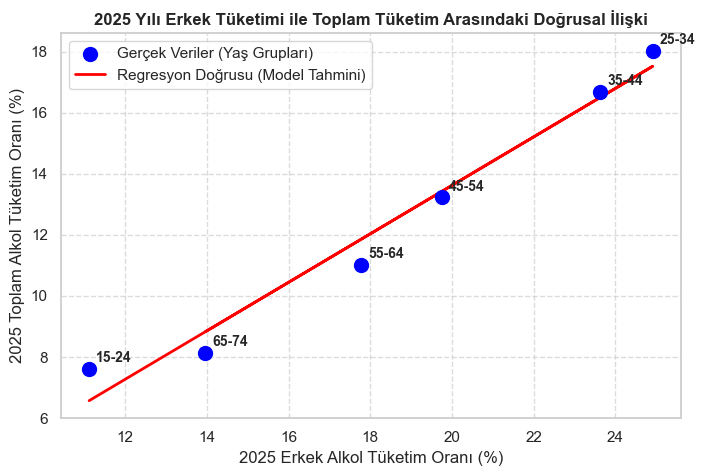

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. VERİNİN MODEL İÇİN HAZIRLANMASI (X ve y Değişkenleri)
# =============================================================================
# Bağımsız Değişken (Girdi): 2025 Yılı Erkek Oranları
X = df_kullanan[['2025_Erkek']].values

# Bağımlı Değişken (Hedef): 2025 Yılı Toplam Oranı
y = df_kullanan['2025_Toplam'].values

# =============================================================================
# 2. MODELİN KURULMASI VE EĞİTİLMESİ
# =============================================================================
model = LinearRegression()
model.fit(X, y) # Modeli eğitiyoruz

# Modelin tahmin değerlerini üretelim
y_pred = model.predict(X)

# =============================================================================
# 3. MODEL PERFORMANS METRİKLERİ 
# =============================================================================
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("=== DOĞRUSAL REGRESYON MODEL SONUÇLARI ===")
print(r2) # Modelin açıklayıcılık gücü
print(f"Eğim (Slope / Coeff): {model.coef_[0]:.4f}")
print(f"Kesişim Noktası (Intercept): {model.intercept_:.4f}")
print(f"R-Kare (R²) Skoru: {r2:.4f}")
print(f"Hata Kareler Ortalaması (MSE): {mse:.4f}")
print(f"Kök Hata Kareler Ortalaması (RMSE): {rmse:.4f}\n")

# =============================================================================
# 4. REGRESYON DOĞRUSUNUN GÖRSELLEŞTİRİLMESİ
# =============================================================================
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Gerçek Veriler (Yaş Grupları)', s=100, zorder=5)
plt.plot(X, y_pred, color='red', linewidth=2, label='Regresyon Doğrusu (Model Tahmini)')

# Derinlik katmak için Grafik üzerine her noktanın hangi yaş grubuna ait olduğunu yazalım 
for i, txt in enumerate(df_kullanan.index):
    plt.annotate(txt, (X[i], y[i]), xytext=(5, 5), textcoords='offset points', fontsize=10, weight='bold')

plt.title('2025 Yılı Erkek Tüketimi ile Toplam Tüketim Arasındaki Doğrusal İlişki', fontsize=12, fontweight='bold')
plt.xlabel('2025 Erkek Alkol Tüketim Oranı (%)')
plt.ylabel('2025 Toplam Alkol Tüketim Oranı (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('regresyon_modeli.png', dpi=300)
plt.show()